In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib import cm

In [2]:
KUKA_cmd_pose_trajs = torch.load(
    '/home/idsia/SonoGym/source/spinal_surgery/spinal_surgery/recordings/robot_US_guidance/cmd_pose_trajs_yu.pt',
    map_location=torch.device('cpu')
)
print("KUKA_cmd_pose_trajs:", KUKA_cmd_pose_trajs.shape)

KUKA_goal_cmd_pose = torch.load(
    '/home/idsia/SonoGym/source/spinal_surgery/spinal_surgery/recordings/robot_US_guidance/goal_cmd_pose_yu.pt',
    map_location=torch.device('cpu')
)
print("KUKA_goal_cmd_pose:", KUKA_goal_cmd_pose.shape)

KUKA_dq_norm_trajs = torch.load(
    '/home/idsia/SonoGym/source/spinal_surgery/spinal_surgery/recordings/robot_US_guidance_G1/dq_norm_trajs.pt',
    map_location=torch.device('cpu')
)
print("KUKA_dq_norm_trajs:", KUKA_dq_norm_trajs.shape)


# --- G1 ---
G1_cmd_pose_trajs = torch.load(
    '/home/idsia/SonoGym/source/spinal_surgery/spinal_surgery/recordings/robot_US_guidance_G1/cmd_pose_trajs.pt',
    map_location=torch.device('cpu')
)
print("G1_cmd_pose_trajs:", G1_cmd_pose_trajs.shape)

G1_goal_cmd_pose = torch.load(
    '/home/idsia/SonoGym/source/spinal_surgery/spinal_surgery/recordings/robot_US_guidance_G1/goal_cmd_pose.pt',
    map_location=torch.device('cpu')
)
print("G1_goal_cmd_pose:", G1_goal_cmd_pose.shape)

G1_dq_norm_trajs = torch.load(
    '/home/idsia/SonoGym/source/spinal_surgery/spinal_surgery/recordings/robot_US_guidance_G1/dq_norm_trajs.pt',
    map_location=torch.device('cpu')
)
print("G1_dq_norm_trajs:", G1_dq_norm_trajs.shape)

KUKA_cmd_pose_trajs: torch.Size([64, 600, 3])
KUKA_goal_cmd_pose: torch.Size([64, 3])
KUKA_dq_norm_trajs: torch.Size([64, 1198])
G1_cmd_pose_trajs: torch.Size([64, 600, 3])
G1_goal_cmd_pose: torch.Size([64, 3])
G1_dq_norm_trajs: torch.Size([64, 1198])


In [3]:
def plot_colored_by_x(x, y, ax, cmap="viridis", linewidth=2, alpha=0.5):
    """
    Plots a 2D line with color based on x values.

    Parameters:
    - x, y: 1D arrays of equal length.
    - cmap: Matplotlib colormap name.
    - linewidth: Width of the line segments.
    - colorbar_label: Label for the colorbar.
    - title: Plot title.
    """

    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")

    # Create segments
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Normalize and map colors based on x
    time_step = -np.log(np.linspace(0, 1, len(x))) / 5
    colors = cm.get_cmap(cmap)(time_step)

    # Create and add LineCollection
    lc = LineCollection(segments, colors=colors, linewidth=linewidth, alpha=alpha)

    ax.add_collection(lc)
    

/tmp/ipykernel_460980/2508749242.py:21: RuntimeWarning: divide by zero encountered in log
  time_step = -np.log(np.linspace(0, 1, len(x))) / 5
/tmp/ipykernel_460980/2508749242.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap(cmap)(time_step)


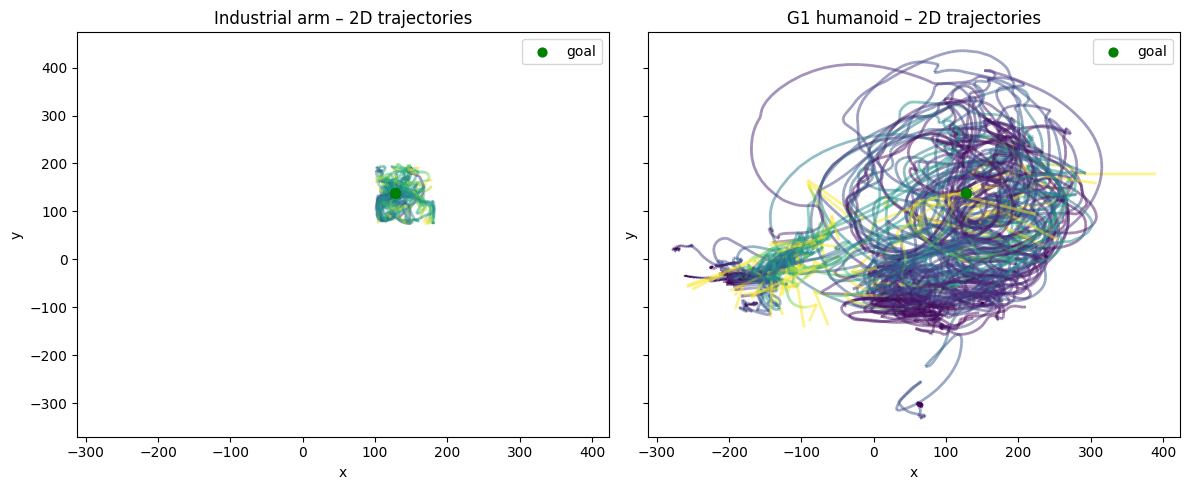

In [4]:
# --- Compute average distances for PPO (industrial arm) ---

# Average 2D position distance per timestep
KUKA_pos_diff = KUKA_cmd_pose_trajs[:, :, :2] - KUKA_goal_cmd_pose[:, :2].unsqueeze(1)  # (N, T, 2)
KUKA_ave_pos_distance = torch.linalg.norm(KUKA_pos_diff, dim=-1).mean(dim=0)   # (T,)

# Average angle distance per timestep
KUKA_angle_diff = torch.abs(
    KUKA_cmd_pose_trajs[:, :, 2] - KUKA_goal_cmd_pose[:, 2].unsqueeze(1)
)  # (N, T)
KUKA_ave_angle_distance = KUKA_angle_diff.mean(dim=0)  # (T,)


# --- Compute average distances for PPO-G1 (humanoid G1) ---

G1_pos_diff = G1_cmd_pose_trajs[:, :, :2] - G1_goal_cmd_pose[:, :2].unsqueeze(1)  # (N, T, 2)
G1_ave_pos_distance = torch.linalg.norm(G1_pos_diff, dim=-1).mean(dim=0)         # (T,)

G1_angle_diff = torch.abs(
    G1_cmd_pose_trajs[:, :, 2] - G1_goal_cmd_pose[:, 2].unsqueeze(1)
)  # (N, T)
G1_ave_angle_distance = G1_angle_diff.mean(dim=0)  # (T,)


# --- Plot 2D trajectories side by side ---

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

ax0, ax1 = axes

# Left: industrial arm PPO trajectories
for traj in range(KUKA_cmd_pose_trajs.shape[0]):
    x = KUKA_cmd_pose_trajs[traj, :, 0].numpy()
    y = KUKA_cmd_pose_trajs[traj, :, 1].numpy()
    plot_colored_by_x(x, y, ax0)

ax0.autoscale()
ax0.set_xlabel("x")
ax0.set_ylabel("y")
ax0.set_title("Industrial arm – 2D trajectories")

ax0.scatter(
    KUKA_goal_cmd_pose[:, 0].numpy(),
    KUKA_goal_cmd_pose[:, 1].numpy(),
    c="green",
    s=40,
    label="goal",
    zorder=2,
)
ax0.legend(loc="best")


# Right: G1 PPO trajectories
for traj in range(G1_cmd_pose_trajs.shape[0]):
    x_g1 = G1_cmd_pose_trajs[traj, :, 0].numpy()
    y_g1 = G1_cmd_pose_trajs[traj, :, 1].numpy()
    plot_colored_by_x(x_g1, y_g1, ax1)

ax1.autoscale()
ax1.set_xlabel("x")
ax1.set_ylabel("y")  # shared y-label makes comparison easier
ax1.set_title("G1 humanoid – 2D trajectories")

ax1.scatter(
    G1_goal_cmd_pose[:, 0].numpy(),
    G1_goal_cmd_pose[:, 1].numpy(),
    c="green",
    s=40,
    label="goal",
    zorder=2,
)
ax1.legend(loc="best")

plt.tight_layout()
plt.show()

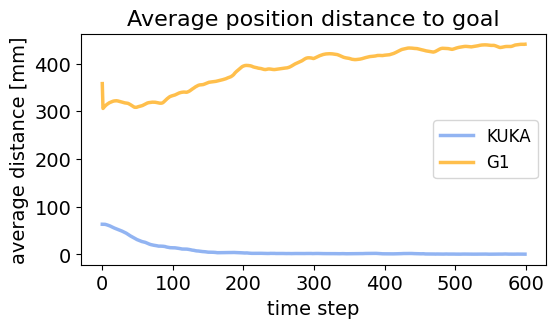

In [5]:
plt.rcParams.update({
    "font.size": 14,          # Base font size
    "axes.titlesize": 16,     # Title size
    "axes.labelsize": 14,     # X/Y label size
    "xtick.labelsize": 14,    # Tick label size
    "ytick.labelsize": 14,
    "legend.fontsize": 12,    # Legend text size
    "figure.titlesize": 18    # Figure title (if used)
})

fig, ax = plt.subplots()
fig.set_size_inches(6, 3)
ax.plot(KUKA_ave_pos_distance * 1.5, label='KUKA', color='cornflowerblue', linewidth=2.5, alpha=0.7)
ax.plot(G1_ave_pos_distance * 1.5, label='G1', color='orange', linewidth=2.5, alpha=0.7)
ax.set_xlabel("time step")
ax.set_ylabel("average distance [mm]")
ax.set_title('Average position distance to goal')
ax.legend()
plt.show()

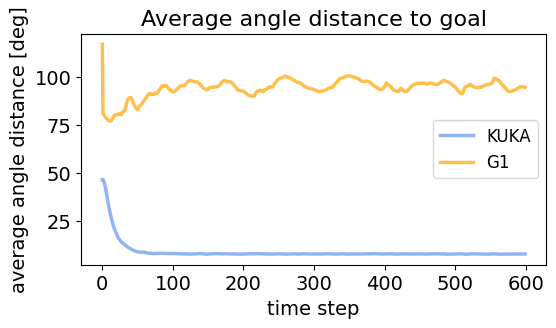

In [6]:
fig, ax = plt.subplots()
fig.set_size_inches(6, 3)
ax.plot(KUKA_ave_angle_distance * 180 / np.pi, label='KUKA', color='cornflowerblue', linewidth=2.5, alpha=0.7)
ax.plot(G1_ave_angle_distance * 180 / np.pi, label='G1', color='orange', linewidth=2.5, alpha=0.7)
ax.set_xlabel("time step")
ax.set_ylabel("average angle distance [deg]")
ax.set_title('Average angle distance to goal')
ax.legend()
plt.show()

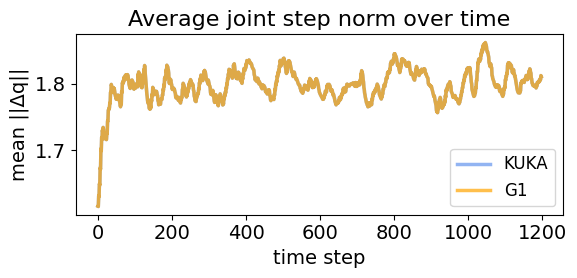

In [7]:
# Compute mean ||dq|| over environments for each timestep
KUKA_dq_mean = KUKA_dq_norm_trajs.mean(dim=0)  # (T,)
G1_dq_mean   = G1_dq_norm_trajs.mean(dim=0)    # (T,)

# Optional: convert to numpy for plotting
KUKA_dq_mean_np = KUKA_dq_mean.numpy()
G1_dq_mean_np   = G1_dq_mean.numpy()

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})

fig, ax = plt.subplots()
fig.set_size_inches(6, 3)

ax.plot(KUKA_dq_mean_np, label='KUKA', color='cornflowerblue', linewidth=2.5, alpha=0.7)
ax.plot(G1_dq_mean_np,   label='G1',   color='orange',         linewidth=2.5, alpha=0.7)

ax.set_xlabel("time step")
ax.set_ylabel("mean ||Δq||")
ax.set_title("Average joint step norm over time")
ax.legend()
plt.tight_layout()
plt.show()